In [1]:
## 导入相关工具类
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import copy
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
"""## 定义数据集(Dataset)类 用于数据读取与处理"""

class Dataset_ETT_minute(Dataset):
    def __init__(self, data_path, context_points, target_points, split='train'):
        # 确保划分类型正确
        assert split in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}
        self.set_type = type_map[split]

        # 设置预测长度和序列长度
        self.pred_len = target_points
        self.seq_len = context_points

        # 读取原始数据
        df_raw = pd.read_csv(data_path)

        # 定义不同数据集的边界索引
        border1s = [0, 12 * 30 * 24 * 4 - self.seq_len, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4 - self.seq_len]
        border2s = [12 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 8 * 30 * 24 * 4]

        # 根据划分类型选择相应的边界
        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]

        # 选择数据列，排除第一列（通常是时间戳）
        cols_data = df_raw.columns[1:]
        df_data = df_raw[cols_data]

        # 获取训练数据部分并进行标准化
        self.scaler = StandardScaler()
        train_data = df_data[border1s[0]:border2s[0]]
        self.scaler.fit(train_data.values)
        data = self.scaler.transform(df_data.values)

        # 根据边界索引切分输入和目标数据
        self.data_x = data[border1:border2]
        self.data_y = data[border1:border2]

    def __getitem__(self, index):
        # 计算输入序列的起始和结束位置
        s_begin = index
        s_end = s_begin + self.seq_len
        # 计算预测序列的起始和结束位置
        r_begin = s_end
        r_end = r_begin + self.pred_len

        # 获取输入序列和目标序列
        seq_x = self.data_x[s_begin:s_end]
        seq_y = self.data_y[s_end:r_end]

        # 将数据转换为浮点型张量
        return torch.from_numpy(seq_x).float(), torch.from_numpy(seq_y).float()

    def __len__(self):
        # 返回数据集的长度，确保不会超出边界
        return len(self.data_x) - self.seq_len - self.pred_len + 1
    

In [3]:
"""## 定义模型"""

class Linear(nn.Module):
    def __init__(self, context_points=96, target_points=96):
        """
        - context_points (int): 回望步长
        - target_points (int): 预测步长
        """
        super(Linear, self).__init__()
        # 定义一个线性层，输入维度为 context_points，输出维度为 target_points
        self.linear = nn.Linear(context_points, target_points)

    def forward(self, x):
        """
        - x: batch_size, target_points, n_vars
        """
        # 转置张量，将维度从 (batch_size, target_points, n_vars) 变为 (batch_size, n_vars, target_points)
        x = x.transpose(1, 2)
        # 通过线性层进行线性变换
        x = self.linear(x)
        # 转置回原始维度顺序，得到 (batch_size, target_points, target_points)
        return x.transpose(1, 2)

In [4]:
"""## 配置训练参数"""

# 设置训练的总轮数
epoches = 10
# 定义输入序列的长度（回望步长）
context_points = 96
# 定义输出序列的长度（预测步长）
target_points = 96
# 定义每个批次的样本数量
batch_size = 64
# 设置学习率，用于优化器更新模型参数的步长
learning_rate = 1e-3
# 指定数据集的路径
data_path = './data/ETTm2.csv'
# 检查是否有可用的GPU，如果有则使用GPU，否则使用CPU
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [5]:
"""## 加载数据"""

# 获取数据加载器
# 创建训练集、验证集和测试集的Dataset实例
train_dataset = Dataset_ETT_minute(data_path, context_points, target_points, 'train')
val_dataset = Dataset_ETT_minute(data_path, context_points, target_points, 'val')
test_dataset = Dataset_ETT_minute(data_path, context_points, target_points, 'test')

# 使用DataLoader将Dataset封装为可迭代的数据加载器
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
val_loader = DataLoader(val_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=batch_size)

In [6]:
"""## 加载模型、损失函数与优化器"""

# 初始化模型
model = Linear(context_points, target_points) # 可以在这里替换你想使用的模型
model.to(device)

# 损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [7]:
"""## 模型训练"""

best_val_loss = float('inf')
best_model_state = copy.deepcopy(model.state_dict())

all_train_losses = []  # 保存每个epoch的平均训练损失
all_val_losses = []    # 保存每个epoch的平均验证损失

for epoch in range(epoches):
    # 设置模型为训练模式
    model.train()
    train_losses = []
    for batch_x, batch_y in train_loader:
        # 将输入和目标数据移动到指定设备（GPU或CPU）
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # 前向传播：通过模型获取输出
        outputs = model(batch_x)

        # 计算损失：比较模型输出与真实目标
        loss = criterion(outputs, batch_y)

        # 优化器梯度清零
        optimizer.zero_grad()

        # 反向传播：计算梯度
        loss.backward()

        # 优化器更新模型参数
        optimizer.step()
        train_losses.append(loss.item())

    # 设置模型为评估模式
    model.eval()


    val_losses = []
    # 禁用梯度计算以加快验证速度
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # 将输入和目标数据移动到指定设备
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # 前向传播：通过模型获取输出
            outputs = model(batch_x)

            # 计算损失：比较模型输出与真实目标
            loss = criterion(outputs, batch_y)

            val_losses.append(loss.item())

    # 计算当前epoch的平均训练损失
    avg_train_loss = np.mean(train_losses)

    # 计算当前epoch的平均验证损失
    avg_val_loss = np.mean(val_losses)
    
    all_train_losses.append(avg_train_loss)
    all_val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epoches}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # 检查当前验证损失是否优于最佳验证损失
    if avg_val_loss < best_val_loss:
        # 更新最佳验证损失
        best_val_loss = avg_val_loss

        # 保存当前模型状态作为最佳模型
        best_model_state = copy.deepcopy(model.state_dict())

        print(f"--> Best model found at epoch {epoch+1} with Val Loss: {best_val_loss:.4f}")


Epoch [1/10], Train Loss: 0.2692, Val Loss: 0.1424
--> Best model found at epoch 1 with Val Loss: 0.1424
Epoch [2/10], Train Loss: 0.2387, Val Loss: 0.1385
--> Best model found at epoch 2 with Val Loss: 0.1385
Epoch [3/10], Train Loss: 0.2357, Val Loss: 0.1438
Epoch [4/10], Train Loss: 0.2337, Val Loss: 0.1486
Epoch [5/10], Train Loss: 0.2336, Val Loss: 0.1354
--> Best model found at epoch 5 with Val Loss: 0.1354
Epoch [6/10], Train Loss: 0.2331, Val Loss: 0.1388
Epoch [7/10], Train Loss: 0.2330, Val Loss: 0.1392
Epoch [8/10], Train Loss: 0.2334, Val Loss: 0.1466
Epoch [9/10], Train Loss: 0.2323, Val Loss: 0.1428
Epoch [10/10], Train Loss: 0.2325, Val Loss: 0.1365


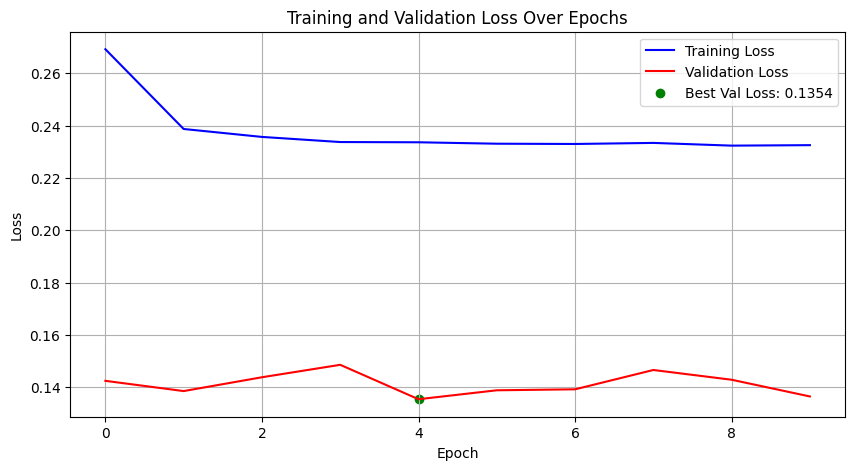

In [8]:
# 训练完成后，绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(all_train_losses, label='Training Loss', color='blue')
plt.plot(all_val_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 标记最佳验证点
best_epoch = all_val_losses.index(best_val_loss)
plt.scatter(best_epoch, best_val_loss, color='green', label=f'Best Val Loss: {best_val_loss:.4f}')
plt.legend()

plt.show()

In [9]:
"""## 模型测试"""

# 加载最佳模型状态
model.load_state_dict(best_model_state)

# 将模型设置为评估模式，禁用Dropout等训练特有的层
model.eval()
test_losses = []
all_preds = []
all_targets = []
all_inputs = []

# 禁用梯度计算，以加快测试过程并减少内存消耗
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # 将输入和目标数据移动到指定设备（GPU或CPU）
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # 前向传播：通过模型获取输出
        outputs = model(batch_x)

        # 计算损失：比较模型输出与真实目标
        loss = criterion(outputs, batch_y)

        # 记录当前批次的测试损失
        test_losses.append(loss.item())

        all_inputs.append(batch_x.cpu().numpy())
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

avg_test_loss = np.mean(test_losses)

# 计算指标
all_inputs = np.concatenate(all_inputs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# 获取预测结果的形状信息
batch_size, forecast_len, n_vars = all_preds.shape

print(all_targets.shape)
# 计算平均绝对误差 (MAE)
mae = mean_absolute_error(all_targets.reshape(-1, n_vars), all_preds.reshape(-1, n_vars))

# 计算均方误差 (MSE)
mse = mean_squared_error(all_targets.reshape(-1, n_vars), all_preds.reshape(-1, n_vars))

# 打印测试集的MAE和MSE
print(f"Test MAE: {mae:.4f}, Test MSE: {mse:.4f}")


(11425, 96, 7)
Test MAE: 0.2953, Test MSE: 0.1981
